In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from wrf_io import *
from scipy.io import savemat
from MITRotor import IEA10MW
from itertools import product
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler

## Train data

In [3]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/'

In [4]:
casenames = [
r's000_v000'
]

In [61]:
params_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/parameters.pkl'

train_data = gpr.generate_train_data(casenames, params_path, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer           : [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]
excluded_pairs : []
Ufst           : 7


In [9]:
train_data.keys()

dict_keys(['r_annulus', 'cot_local', 'ind_local', 'cot_annulus', 'ind_annulus', 'cot_rotor', 'ind_rotor', 'shears_rotor', 'veers_rotor', 'shears_annulus', 'veers_annulus'])

In [54]:
np.linspace(0,0.99999,26)

array([0.       , 0.0399996, 0.0799992, 0.1199988, 0.1599984, 0.199998 ,
       0.2399976, 0.2799972, 0.3199968, 0.3599964, 0.399996 , 0.4399956,
       0.4799952, 0.5199948, 0.5599944, 0.599994 , 0.6399936, 0.6799932,
       0.7199928, 0.7599924, 0.799992 , 0.8399916, 0.8799912, 0.9199908,
       0.9599904, 0.99999  ])

In [62]:
train_data['ind_rotor']

array([0.24998732])

In [63]:
train_data['cot_rotor']

array([0.71483355])

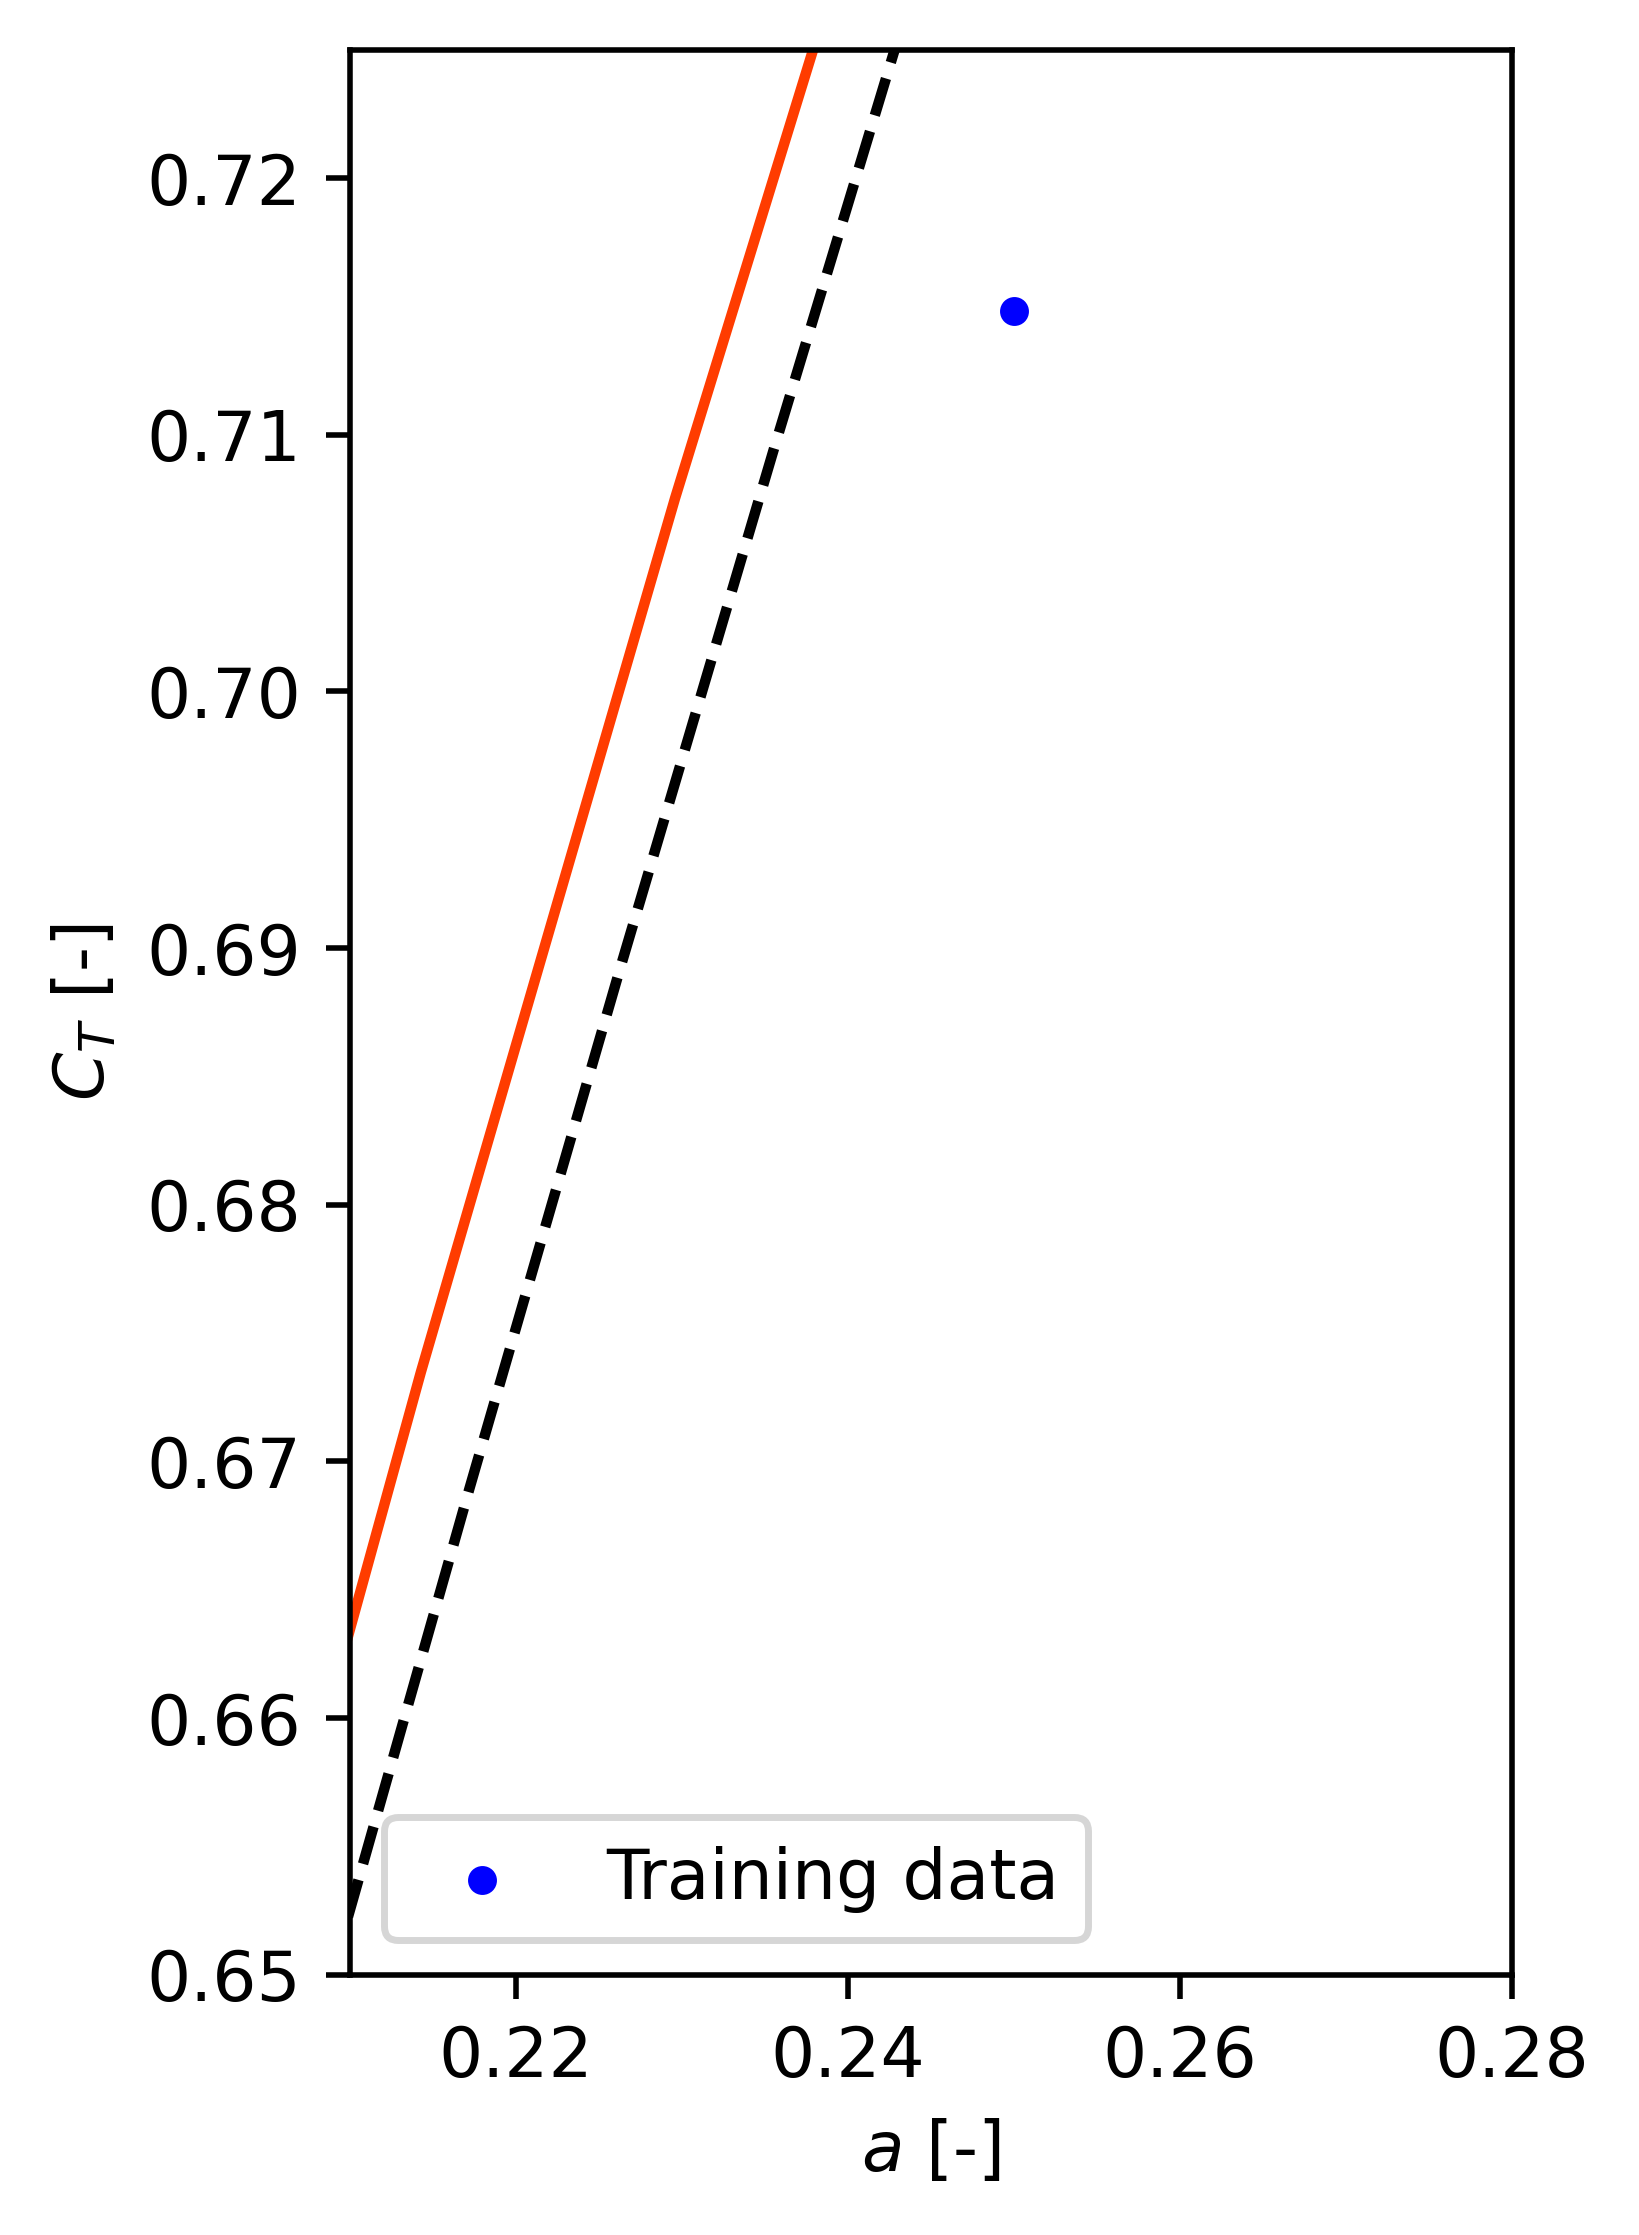

In [64]:

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 5))

ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
ax.plot(a_mad,ct_mad,'k--',zorder=1)
ax.scatter(train_data['ind_rotor'],train_data['cot_rotor'],10,color='b',label='Training data')

ax.set_xlim([0.21,0.28])
ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

ax.legend()

In [71]:
# Merge original training set with near-origin training set
training_data = gpr.merge_data_dicts(train_data, train_data_near_origin)

In [72]:
gpr.print_stats(training_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
r_annulus            |    0.51206 |    0.28150 |    0.04289 |    0.98123
cot_local            |    0.71145 |    0.30817 |    0.07331 |    1.19589
ind_local            |    0.23985 |    0.14885 |   -0.37177 |    0.63959
cot_annulus          |    0.71145 |    0.30021 |    0.10309 |    1.04093
ind_annulus          |    0.23985 |    0.10887 |   -0.00722 |    0.35786
cot_rotor            |    0.68692 |    0.00644 |    0.67045 |    0.70221
ind_rotor            |    0.24468 |    0.00953 |    0.22182 |    0.26756
shears_rotor         |   -0.00000 |    0.01860 |   -0.03000 |    0.03000
veers_rotor          |   -0.00000 |    0.10113 |   -0.20000 |    0.20000
shears_annulus       |    0.00000 |    0.01860 |   -0.03000 |    0.03000
veers_annulus        |  

In [73]:
# Compute shear regime, generate scalars, and standardize
training_data, scalars = gpr.scale_and_encode(training_data, training=True)

cot_local: scaler trained with 1 features
ind_local: scaler trained with 1 features
cot_annulus: scaler trained with 1 features
ind_annulus: scaler trained with 1 features
cot_rotor: scaler trained with 1 features
ind_rotor: scaler trained with 1 features
shears_rotor: scaler trained with 1 features
veers_rotor: scaler trained with 1 features
shears_annulus: scaler trained with 1 features
veers_annulus: scaler trained with 1 features


In [74]:
gpr.print_stats(training_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
shear_regime_rotor   |    0.25000 |    0.43301 |    0.00000 |    1.00000
shear_regime_annulus |    0.25000 |    0.43301 |    0.00000 |    1.00000
r_annulus            |    0.51206 |    0.28150 |    0.04289 |    0.98123
cot_local            |    0.00000 |    1.00000 |   -2.07071 |    1.57200
ind_local            |   -0.00000 |    1.00000 |   -4.10900 |    2.68555
cot_annulus          |   -0.00000 |    1.00000 |   -2.02644 |    1.09750
ind_annulus          |    0.00000 |    1.00000 |   -2.26947 |    1.08399
cot_rotor            |   -0.00000 |    1.00000 |   -2.55443 |    2.37278
ind_rotor            |   -0.00000 |    1.00000 |   -2.39690 |    2.39936
shears_rotor         |    0.00000 |    1.00000 |   -1.61267 |    1.61267
veers_rotor          |  

In [75]:
scalars

{'encoder_rotor': OneHotEncoder(sparse_output=False),
 'encoder_annulus': OneHotEncoder(sparse_output=False),
 'scaler_cot_local': StandardScaler(),
 'scaler_ind_local': StandardScaler(),
 'scaler_cot_annulus': StandardScaler(),
 'scaler_ind_annulus': StandardScaler(),
 'scaler_cot_rotor': StandardScaler(),
 'scaler_ind_rotor': StandardScaler(),
 'scaler_shears_rotor': StandardScaler(),
 'scaler_veers_rotor': StandardScaler(),
 'scaler_shears_annulus': StandardScaler(),
 'scaler_veers_annulus': StandardScaler()}

In [15]:
# # Generate MATLAB inputs for GP search

# X_rot = np.column_stack([cot_rot_f, shears_f, veers_f])
# X_ann = np.column_stack([r_ann_f.flatten(), cot_ann_f.flatten(), shears_ann_f.flatten(), veers_ann_f.flatten()])

# X_rot = np.hstack([X_rot, onehot_rot])
# X_ann = np.hstack([X_ann, onehot_ann])

# y_rot = ind_rot_f
# y_ann = ind_ann_f.flatten()

# savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
# savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

In [ ]:
with open(os.path.join(save_path, 'scaler_wrf_cot_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_cot_annulus'], f)

with open(os.path.join(save_path, 'scaler_wrf_ind_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_ind_annulus'], f)

with open(os.path.join(save_path, 'scaler_wrf_cot_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_cot_rotor'], f)

with open(os.path.join(save_path, 'scaler_wrf_ind_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_ind_rotor'], f)

with open(os.path.join(save_path, 'scaler_shears_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_shears_rotor'], f)

with open(os.path.join(save_path, 'scaler_veers_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_veers_rotor'], f)

with open(os.path.join(save_path, 'scaler_shears_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_shears_annulus'], f)

with open(os.path.join(save_path, 'scaler_veers_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['scaler_veers_annulus'], f)

with open(os.path.join(save_path, 'encoder_rot.pkl'), 'wb') as f:
    pickle.dump(scalars['encoder_rotor'], f)

with open(os.path.join(save_path, 'encoder_ann.pkl'), 'wb') as f:
    pickle.dump(scalars['encoder_annulus'], f)

## Validation data

In [79]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/'

In [80]:
casenames = [
r'sn0300_vn2500',
r'sn0300_vn1500',
r'sn0300_vn0750',
r'sn0300_vn0350',
r'sn0300_v0350',
r'sn0300_v0750',
r'sn0300_v1500',
r'sn0300_v2500',
r'sn0200_vn2500',
r'sn0200_vn1500',
r'sn0200_vn0750',
r'sn0200_vn0350',
r'sn0200_v0350',
r'sn0200_v0750',
r'sn0200_v1500',
r'sn0200_v2500',
r'sn0100_vn2500',
r'sn0100_vn1500',
r'sn0100_vn0750',
r'sn0100_vn0350',
r'sn0100_v0350',
r'sn0100_v0750',
r'sn0100_v1500',
r'sn0100_v2500',
r'sn0025_vn2500',
r'sn0025_vn1500',
r'sn0025_vn0750',
r'sn0025_vn0350',
r'sn0025_v0350',
r'sn0025_v0750',
r'sn0025_v1500',
r'sn0025_v2500',
r's0025_vn2500',
r's0025_vn1500',
r's0025_vn0750',
r's0025_vn0350',
r's0025_v0350',
r's0025_v0750',
r's0025_v1500',
r's0025_v2500',
r's0100_vn2500',
r's0100_vn1500',
r's0100_vn0750',
r's0100_vn0350',
r's0100_v0350',
r's0100_v0750',
r's0100_v1500',
r's0100_v2500',
r's0200_vn2500',
r's0200_vn1500',
r's0200_vn0750',
r's0200_vn0350',
r's0200_v0350',
r's0200_v0750',
r's0200_v1500',
r's0200_v2500',
r's0300_vn2500',
r's0300_vn1500',
r's0300_vn0750',
r's0300_vn0350',
r's0300_v0350',
r's0300_v0750',
r's0300_v1500',
r's0300_v2500'
]

In [81]:
params_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/validation/gad_sweep/opt_params.pkl'

validation_data = gpr.generate_train_data(casenames, params_path, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/validation
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, -0.0025, 0.0025, 0.01, 0.02, 0.03]
veer           : [-0.25, -0.15, -0.075, -0.035, 0.035, 0.075, 0.15, 0.25]
Ufst           : 7
excluded_pairs : []


In [82]:
# Print stats of near-origin training data
gpr.print_stats(validation_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
r_annulus            |    0.51206 |    0.28150 |    0.04289 |    0.98123
cot_local            |    0.70849 |    0.30709 |    0.07182 |    1.19925
ind_local            |    0.24356 |    0.15009 |   -0.36387 |    0.65717
cot_annulus          |    0.70849 |    0.29879 |    0.10234 |    1.03270
ind_annulus          |    0.24356 |    0.10878 |    0.00202 |    0.36474
cot_rotor            |    0.68425 |    0.00790 |    0.66578 |    0.69974
ind_rotor            |    0.24835 |    0.01103 |    0.22827 |    0.27385
shears_rotor         |    0.00000 |    0.01875 |   -0.03000 |    0.03000
veers_rotor          |    0.00000 |    0.15153 |   -0.25000 |    0.25000
shears_annulus       |    0.00000 |    0.01875 |   -0.03000 |    0.03000
veers_annulus        |  

In [83]:
# Compute shear regime, generate scalars, and standardize
validation_data, _ = gpr.scale_and_encode(validation_data, training=False, scalars=scalars)

[cot_local] training=False, scaler expects 1, got 1
[ind_local] training=False, scaler expects 1, got 1
[cot_annulus] training=False, scaler expects 1, got 1
[ind_annulus] training=False, scaler expects 1, got 1
[cot_rotor] training=False, scaler expects 1, got 1
[ind_rotor] training=False, scaler expects 1, got 1
[shears_rotor] training=False, scaler expects 1, got 1
[veers_rotor] training=False, scaler expects 1, got 1
[shears_annulus] training=False, scaler expects 1, got 1
[veers_annulus] training=False, scaler expects 1, got 1


In [84]:
# Print stats of near-origin training data
gpr.print_stats(validation_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
shear_regime_rotor   |    0.25000 |    0.43301 |    0.00000 |    1.00000
shear_regime_annulus |    0.25000 |    0.43301 |    0.00000 |    1.00000
r_annulus            |    0.51206 |    0.28150 |    0.04289 |    0.98123
cot_local            |   -0.00959 |    0.99651 |   -2.07556 |    1.58292
ind_local            |    0.02491 |    1.00833 |   -4.05592 |    2.80366
cot_annulus          |   -0.00984 |    0.99527 |   -2.02894 |    1.07008
ind_annulus          |    0.03406 |    0.99917 |   -2.18461 |    1.14719
cot_rotor            |   -0.41374 |    1.22529 |   -3.27942 |    1.99039
ind_rotor            |    0.38457 |    1.15683 |   -1.72068 |    3.05910
shears_rotor         |    0.00000 |    1.00792 |   -1.61267 |    1.61267
veers_rotor          |  

In [85]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([validation_data['cot_rotor'], validation_data['shears_rotor'], validation_data['veers_rotor']])
X_ann = np.column_stack([validation_data['r_annulus'].flatten(), validation_data['cot_annulus'].flatten(), validation_data['shears_annulus'].flatten(), validation_data['veers_annulus'].flatten()])

X_rot = np.hstack([X_rot, validation_data['shear_regime_rotor']])
X_ann = np.hstack([X_ann, validation_data['shear_regime_annulus']])

y_rot = validation_data['ind_rotor']
y_ann = validation_data['ind_annulus'].flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

## Test data

In [23]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/'

In [24]:
casenames = [
r'sn035_vn250',
r'sn035_vn150',
r'sn035_vn075',
r'sn035_vn035',
r'sn035_vn010',
r'sn035_v010',
r'sn035_v035',
r'sn035_v075',
r'sn035_v150',
r'sn035_v250',
r'sn025_vn250',
r'sn025_vn150',
r'sn025_vn075',
r'sn025_vn035',
r'sn025_vn010',
r'sn025_v010',
r'sn025_v035',
r'sn025_v075',
r'sn025_v150',
r'sn025_v250',
r'sn015_vn250',
r'sn015_vn150',
r'sn015_vn075',
r'sn015_vn035',
r'sn015_vn010',
r'sn015_v010',
r'sn015_v035',
r'sn015_v075',
r'sn015_v150',
r'sn015_v250',
r'sn005_vn250',
r'sn005_vn150',
r'sn005_vn075',
r'sn005_vn035',
r'sn005_vn010',
r'sn005_v010',
r'sn005_v035',
r'sn005_v075',
r'sn005_v150',
r'sn005_v250',
r's000_vn250',
r's000_vn150',
r's000_vn075',
r's000_vn035',
r's000_vn010',
r's000_v010',
r's000_v035',
r's000_v075',
r's000_v150',
r's000_v250',
r's005_vn250',
r's005_vn150',
r's005_vn075',
r's005_vn035',
r's005_vn010',
r's005_v010',
r's005_v035',
r's005_v075',
r's005_v150',
r's005_v250',
r's015_vn250',
r's015_vn150',
r's015_vn075',
r's015_vn035',
r's015_vn010',
r's015_v010',
r's015_v035',
r's015_v075',
r's015_v150',
r's015_v250',
r's025_vn250',
r's025_vn150',
r's025_vn075',
r's025_vn035',
r's025_vn010',
r's025_v010',
r's025_v035',
r's025_v075',
r's025_v150',
r's025_v250',
r's035_vn250',
r's035_vn150',
r's035_vn075',
r's035_vn035',
r's035_vn010',
r's035_v010',
r's035_v035',
r's035_v075',
r's035_v150',
r's035_v250'
]

In [25]:
# Path to the file
pkl_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_SV/gad_sweep/opt_params.pkl'

# Load the pickle file
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

data['excluded_pairs'] = []
data

# Save it back to the original file
with open(pkl_path, 'wb') as f:
    pickle.dump(data, f)

In [26]:
params_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_SV/gad_sweep/opt_params.pkl'

test_data = gpr.generate_train_data(casenames, params_path, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_SV
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.035, -0.025, -0.015, -0.005, 0, 0.005, 0.015, 0.025, 0.035]
veer           : [-0.25, -0.15, -0.075, -0.035, -0.01, 0.01, 0.035, 0.075, 0.15, 0.25]
Ufst           : 7
excluded_pairs : []


In [27]:
# Print stats of near-origin training data
gpr.print_stats(test_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
r_annulus            |    0.51206 |    0.28150 |    0.04289 |    0.98123
cot_local            |    0.71118 |    0.31076 |    0.06744 |    1.24503
ind_local            |    0.24007 |    0.16048 |   -0.42970 |    0.70689
cot_annulus          |    0.71118 |    0.30019 |    0.10239 |    1.04270
ind_annulus          |    0.24007 |    0.10882 |   -0.00462 |    0.36465
cot_rotor            |    0.68672 |    0.00854 |    0.66638 |    0.70523
ind_rotor            |    0.24490 |    0.01241 |    0.22093 |    0.27381
shears_rotor         |   -0.00000 |    0.02160 |   -0.03500 |    0.03500
veers_rotor          |    0.00000 |    0.13561 |   -0.25000 |    0.25000
shears_annulus       |    0.00000 |    0.02160 |   -0.03500 |    0.03500
veers_annulus        |  

In [28]:
# Compute shear regime, generate scalars, and standardize
test_data, _ = gpr.scale_and_encode(test_data, training=False, scalars=scalars)

[cot_local] training=False, scaler expects 1, got 1
[ind_local] training=False, scaler expects 1, got 1
[cot_annulus] training=False, scaler expects 1, got 1
[ind_annulus] training=False, scaler expects 1, got 1
[cot_rotor] training=False, scaler expects 1, got 1
[ind_rotor] training=False, scaler expects 1, got 1
[shears_rotor] training=False, scaler expects 1, got 1
[veers_rotor] training=False, scaler expects 1, got 1
[shears_annulus] training=False, scaler expects 1, got 1
[veers_annulus] training=False, scaler expects 1, got 1


In [29]:
# Print stats of near-origin training data
gpr.print_stats(test_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
shear_regime_rotor   |    0.25000 |    0.43301 |    0.00000 |    1.00000
shear_regime_annulus |    0.25000 |    0.43301 |    0.00000 |    1.00000
r_annulus            |    0.51206 |    0.28150 |    0.04289 |    0.98123
cot_local            |   -0.00088 |    1.00841 |   -2.08976 |    1.73145
ind_local            |    0.00150 |    1.07815 |   -4.49820 |    3.13766
cot_annulus          |   -0.00090 |    0.99992 |   -2.02876 |    1.10342
ind_annulus          |    0.00205 |    0.99961 |   -2.24561 |    1.14631
cot_rotor            |   -0.03021 |    1.32446 |   -3.18619 |    2.84231
ind_rotor            |    0.02368 |    1.30161 |   -2.49072 |    3.05540
shears_rotor         |   -0.00000 |    1.16125 |   -1.88144 |    1.88144
veers_rotor          |  

In [30]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([test_data['cot_rotor'], test_data['shears_rotor'], test_data['veers_rotor']])
X_ann = np.column_stack([test_data['r_annulus'].flatten(), test_data['cot_annulus'].flatten(), test_data['shears_annulus'].flatten(), test_data['veers_annulus'].flatten()])

y_rot = test_data['ind_rotor']
y_ann = test_data['ind_annulus'].flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

## Test data (OOS rt)

In [31]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/'

In [39]:
casenames = [
# r'sn030_vn200',
# r'sn030_vn100',
# r'sn030_vn050',
# r'sn030_vn025',
# r'sn030_v000',
# r'sn030_v025',
# r'sn030_v050',
# r'sn030_v100',
# r'sn030_v200',
# r'sn020_vn200',
r'sn020_vn100',
# r'sn020_vn050',
# r'sn020_vn025',
r'sn020_v000',
# r'sn020_v025',
# r'sn020_v050',
r'sn020_v100',
# r'sn020_v200',
# r'sn010_vn200',
# r'sn010_vn100',
# r'sn010_vn050',
# r'sn010_vn025',
# r'sn010_v000',
# r'sn010_v025',
# r'sn010_v050',
# r'sn010_v100',
# r'sn010_v200',
# r's000_vn200',
r's000_vn100',
# r's000_vn050',
# r's000_vn025',
r's000_v000',
# r's000_v025',
# r's000_v050',
r's000_v100',
# r's000_v200',
# r's010_vn200',
# r's010_vn100',
# r's010_vn050',
# r's010_vn025',
# r's010_v000',
# r's010_v025',
# r's010_v050',
# r's010_v100',
# r's010_v200',
# r's020_vn200',
r's020_vn100',
# r's020_vn050',
# r's020_vn025',
r's020_v000',
# r's020_v025',
# r's020_v050',
r's020_v100',
# r's020_v200',
# r's030_vn200',
# r's030_vn100',
# r's030_vn050',
# r's030_vn025',
# r's030_v000',
# r's030_v025',
# r's030_v050',
# r's030_v100',
# r's030_v200'
]

In [40]:
params_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_rt_up/gad_sweep/opt_params.pkl'

test_OOSrt_up_data = gpr.generate_train_data(casenames, params_path, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_rt_up
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer           : [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]
excluded_pairs : []
Ufst           : 7


In [41]:
# Print stats of near-origin training data
gpr.print_stats(test_OOSrt_up_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |    0.71581 |    0.29914 |    0.07797 |    1.11967
ind_local            |    0.24220 |    0.13855 |   -0.23131 |    0.52166
cot_annulus          |    0.71581 |    0.29267 |    0.09639 |    1.02050
ind_annulus          |    0.24220 |    0.10601 |    0.01976 |    0.34607
cot_rotor            |    0.68629 |    0.00416 |    0.67889 |    0.69281
ind_rotor            |    0.24566 |    0.00530 |    0.23923 |    0.25607
shears_rotor         |    0.00000 |    0.02000 |   -0.03000 |    0.03000
veers_rotor          |   -0.00000 |    0.10865 |   -0.20000 |    0.20000
shears_annulus       |   -0.03000 |    0.00000 |   -0.03000 |   -0.03000
veers_annulus        |  

In [37]:
# Compute shear regime, generate scalars, and standardize
test_OOSrt_up_data, _ = gpr.scale_and_encode(test_OOSrt_up_data, training=False, scalars=scalars)

[cot_local] training=False, scaler expects 1, got 1
[ind_local] training=False, scaler expects 1, got 1
[cot_annulus] training=False, scaler expects 1, got 1
[ind_annulus] training=False, scaler expects 1, got 1
[cot_rotor] training=False, scaler expects 1, got 1
[ind_rotor] training=False, scaler expects 1, got 1
[shears_rotor] training=False, scaler expects 1, got 1
[veers_rotor] training=False, scaler expects 1, got 1
[shears_annulus] training=False, scaler expects 1, got 1
[veers_annulus] training=False, scaler expects 1, got 1


In [38]:
# Print stats of near-origin training data
gpr.print_stats(test_OOSrt_up_data)

Variable Statistics:
---------------------------------------------------------------------------
Name                 |       Mean |    Std Dev |        Min |        Max
---------------------------------------------------------------------------
shear_regime_rotor   |    0.25000 |    0.43301 |    0.00000 |    1.00000
shear_regime_annulus |    0.25000 |    0.43301 |    0.00000 |    1.00000
r_annulus            |    0.51206 |    0.28156 |    0.04039 |    0.98374
cot_local            |    0.01415 |    0.97069 |   -2.05562 |    1.32466
ind_local            |    0.01575 |    0.93079 |   -3.16538 |    1.89323
cot_annulus          |    0.01452 |    0.97488 |   -2.04875 |    1.02947
ind_annulus          |    0.02154 |    0.97378 |   -2.02168 |    0.97569
cot_rotor            |   -0.09773 |    0.64605 |   -1.24525 |    0.91524
ind_rotor            |    0.10275 |    0.55551 |   -0.57187 |    1.19443
shears_rotor         |   -0.00000 |    1.07511 |   -1.61267 |    1.61267
veers_rotor          |  

In [ ]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([test_data['cot_rotor'], test_data['shears_rotor'], test_data['veers_rotor']])
X_ann = np.column_stack([test_data['r_annulus'].flatten(), test_data['cot_annulus'].flatten(), test_data['shears_annulus'].flatten(), test_data['veers_annulus'].flatten()])

y_rot = test_data['ind_rotor']
y_ann = test_data['ind_annulus'].flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

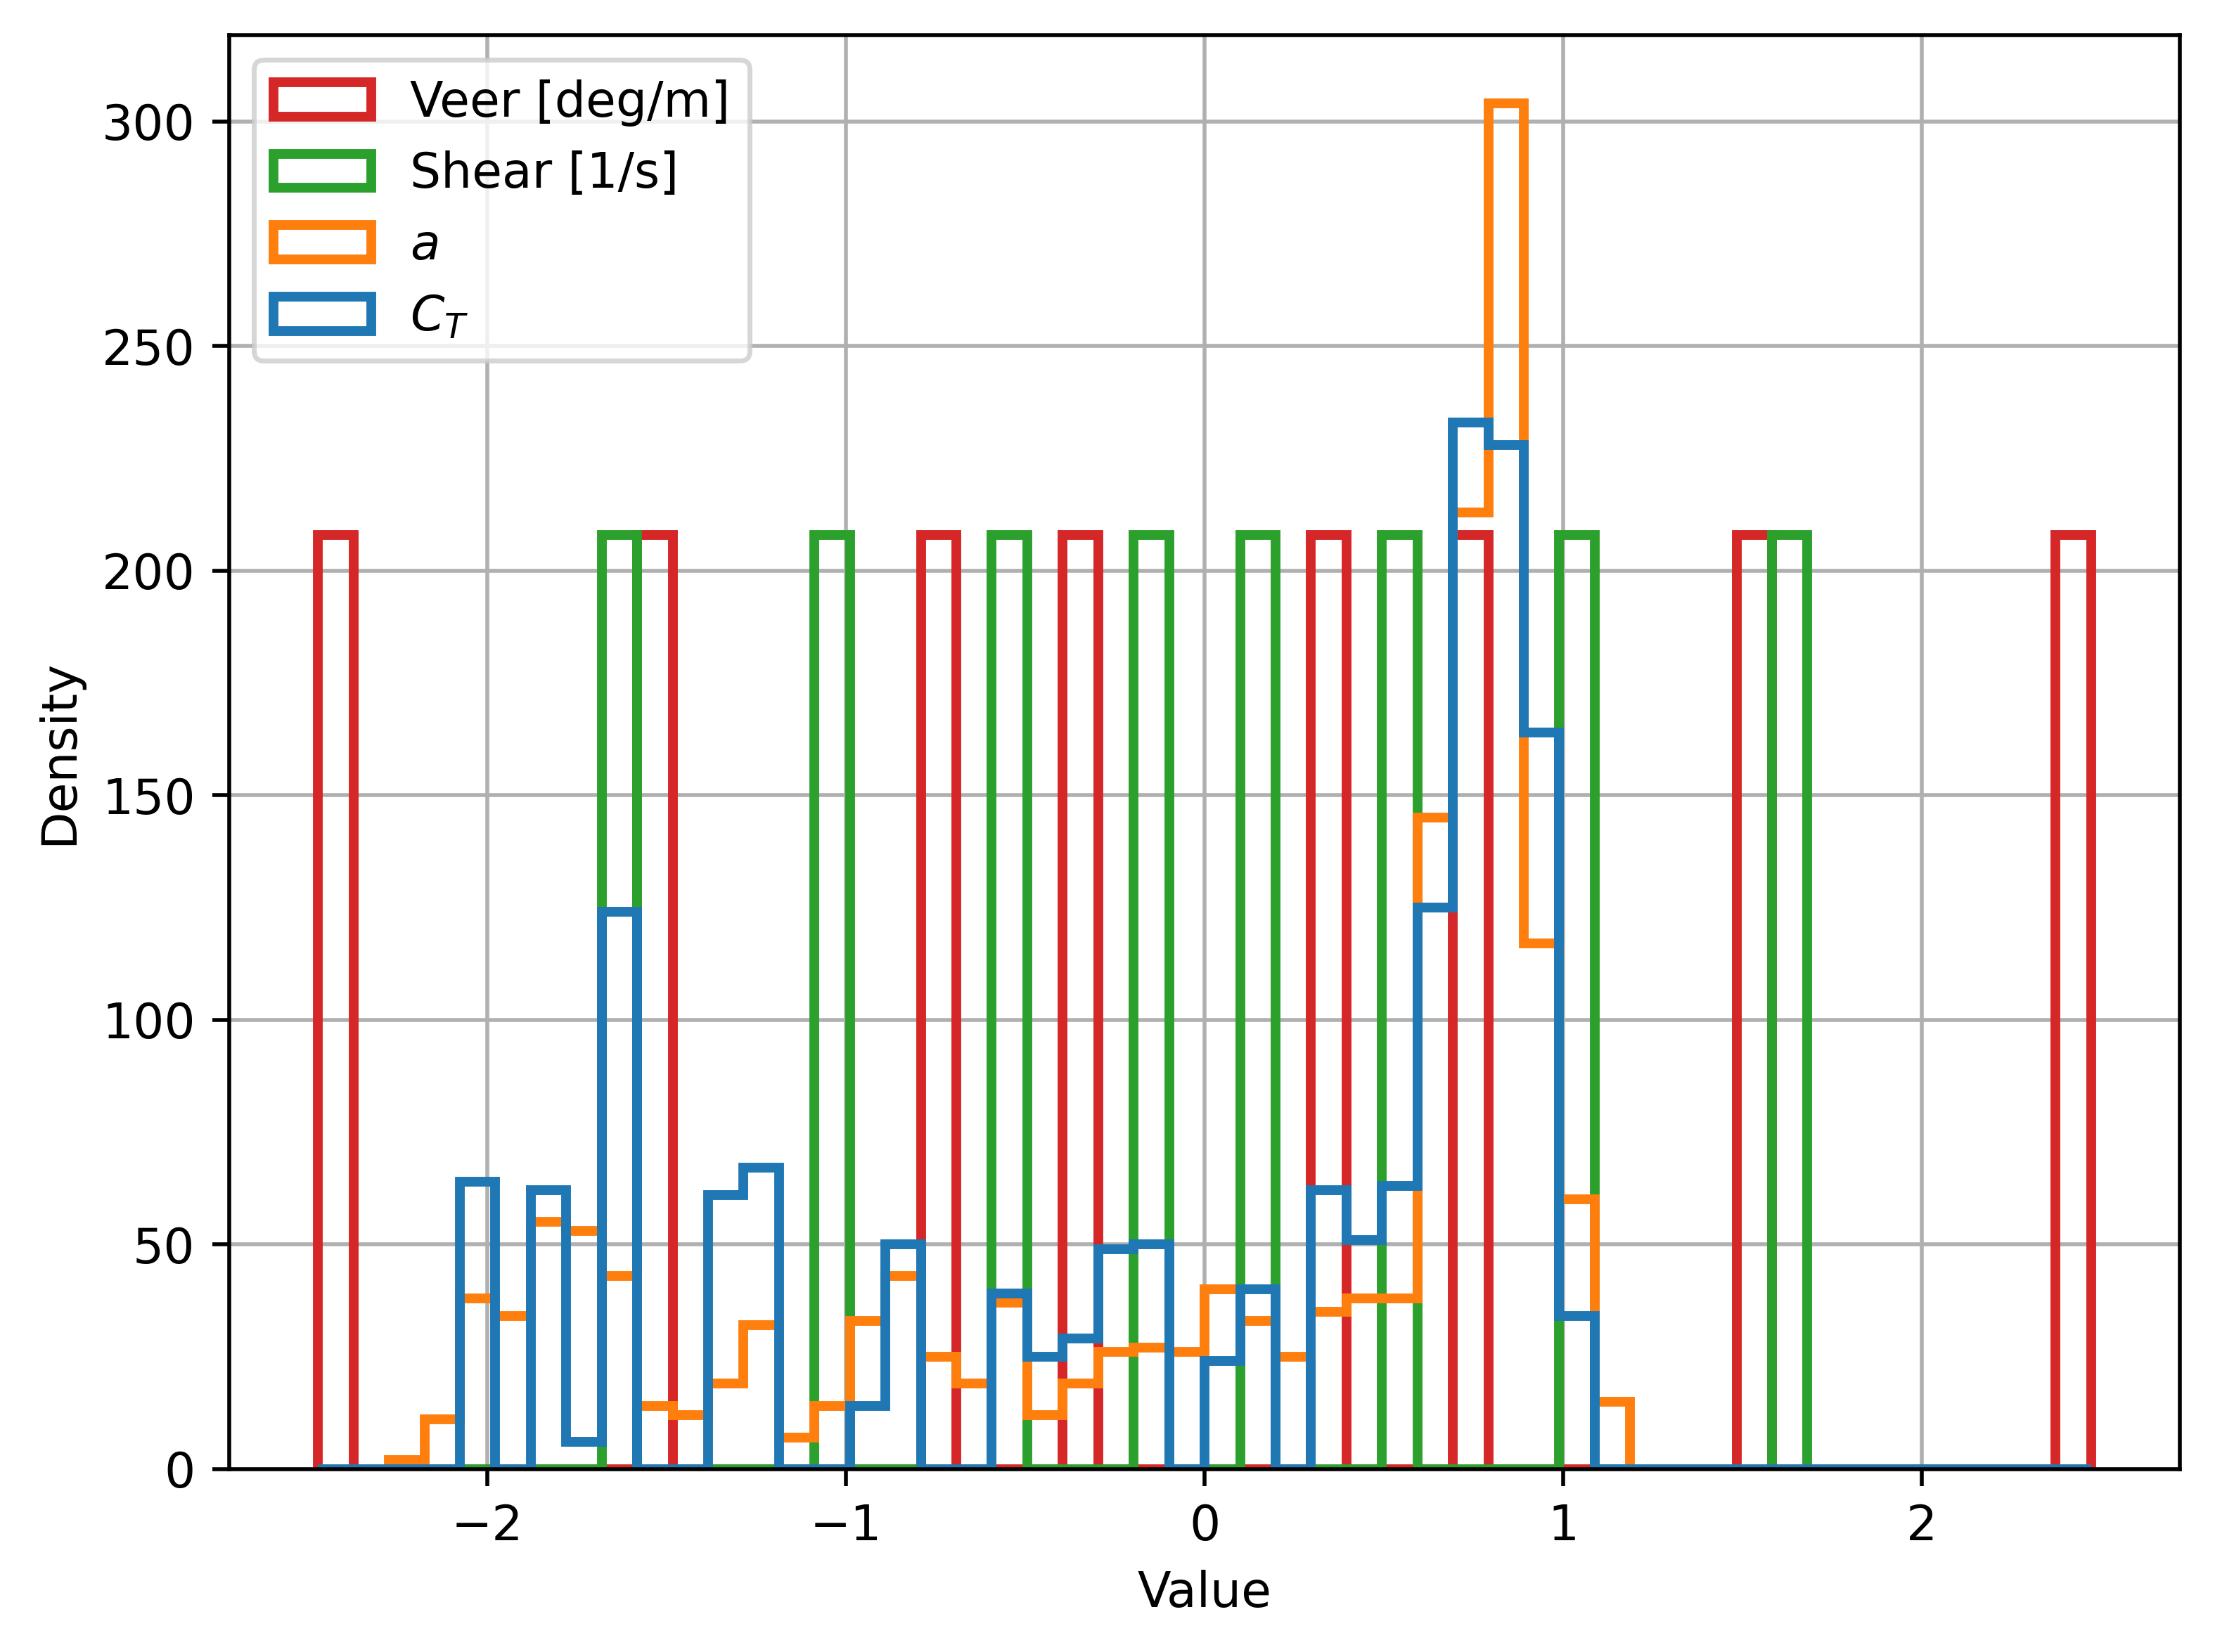

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
# data1 = training_data['cot_annulus'].flatten()
# data2 = training_data['ind_annulus'].flatten()
# data3 = training_data['shears_annulus'].flatten()
# data4 = training_data['veers_annulus'].flatten()

data1 = validation_data['cot_annulus'].flatten()
data2 = validation_data['ind_annulus'].flatten()
data3 = validation_data['shears_annulus'].flatten()
data4 = validation_data['veers_annulus'].flatten()

# Plot as stair/step histograms
plt.hist([data1, data2, data3, data4],
         bins=50,
         density=False,
         histtype='step',
         linewidth=2,
         label=['$C_T$', '$a$', 'Shear [1/s]', 'Veer [deg/m]'])

plt.xlabel('Value')
plt.ylabel('Density')
# plt.title('Step Histogram of Multiple Datasets')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
